# LEAD Dataset
---
Explores the preprocessed downstream datasets used in the [LEAD EEG Foundation Model](https://github.com/DL4mHealth/LEAD) for Alzheimer's Disease detection.

Each dataset lives under `data/lead/<window_length>/<dataset_name>/` and contains:
- `meta.json` — shape metadata, sampling rates, channel count
- `X.dat` — EEG segments as float32 memmap, shape `[N, T, C]`
- `y.dat` — labels as float32 memmap, shape `[N, 3]`: `[label, subject_id, sampling_rate]`

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LEAD_ROOT = "../data/lead"

## 1. Dataset Inventory

In [2]:
# Discover all splits and load their metadata + y.dat summaries
splits = []

for window_dir in sorted(os.listdir(LEAD_ROOT)):
    window_path = os.path.join(LEAD_ROOT, window_dir)
    if not os.path.isdir(window_path):
        continue
    for dataset_dir in sorted(os.listdir(window_path)):
        dataset_path = os.path.join(window_path, dataset_dir)
        meta_path = os.path.join(dataset_path, "meta.json")
        if not os.path.exists(meta_path):
            continue

        with open(meta_path) as f:
            meta = json.load(f)

        N, T, C = meta["N"], meta["T"], meta["C"]
        sr_list = meta["SAMPLE_RATE_LIST"]

        y = np.fromfile(os.path.join(dataset_path, "y.dat"), dtype=np.float32).reshape(N, 3)
        n_subjects  = len(np.unique(y[:, 1]))
        label_counts = {int(k): int(v) for k, v in zip(*np.unique(y[:, 0], return_counts=True))}
        n_classes   = len(label_counts)

        splits.append({
            "Dataset":         dataset_dir,
            "Window (L)": T,
            "Channels (C)": C,
            "Segments (N)": N,
            "Subjects": n_subjects,
            "Classes": n_classes,
            "Sampling Rates (Hz)": str(sr_list),
            "Overlap": meta["OVERLAP"],
            "Step": meta["STEP"],
            "_path": dataset_path,
            "_label_counts": label_counts,
            "_y": y,
        })

inv = pd.DataFrame(splits).drop(columns=["_path", "_label_counts", "_y"])
print("=== LEAD Downstream Datasets ===")
print(inv.to_string(index=False))

=== LEAD Downstream Datasets ===
 Dataset  Window (L)  Channels (C)  Segments (N)  Subjects  Classes Sampling Rates (Hz)  Overlap  Step
   ADFSU         100            19          4048        92        2           [100, 50]       50    50
    ADSZ         100            19          1128        48        2           [100, 50]       50    50
   APAVA         200            16          9282        23        2      [200, 100, 50]      100   100
   ADFTD         400            19        167083        88        3      [200, 100, 50]      200   200
ADFTD-PS         400            19         45258        88        3      [200, 100, 50]      200   200
ADFTD-RS         400            19        121825        88        3      [200, 100, 50]      200   200


## 2. Window & Sampling Rate Design

LEAD uses a **multi-sampling segmentation** strategy: each recording is downsampled to multiple rates and segmented into fixed-length windows. A window of L timestamps corresponds to:

| L   | @ 200 Hz | @ 100 Hz | @ 50 Hz |
|-----|----------|----------|---------|
| 100 | 0.5 s    | 1 s      | 2 s     |
| 200 | 1 s      | 2 s      | 4 s     |
| 400 | 2 s      | 4 s      | 8 s     |

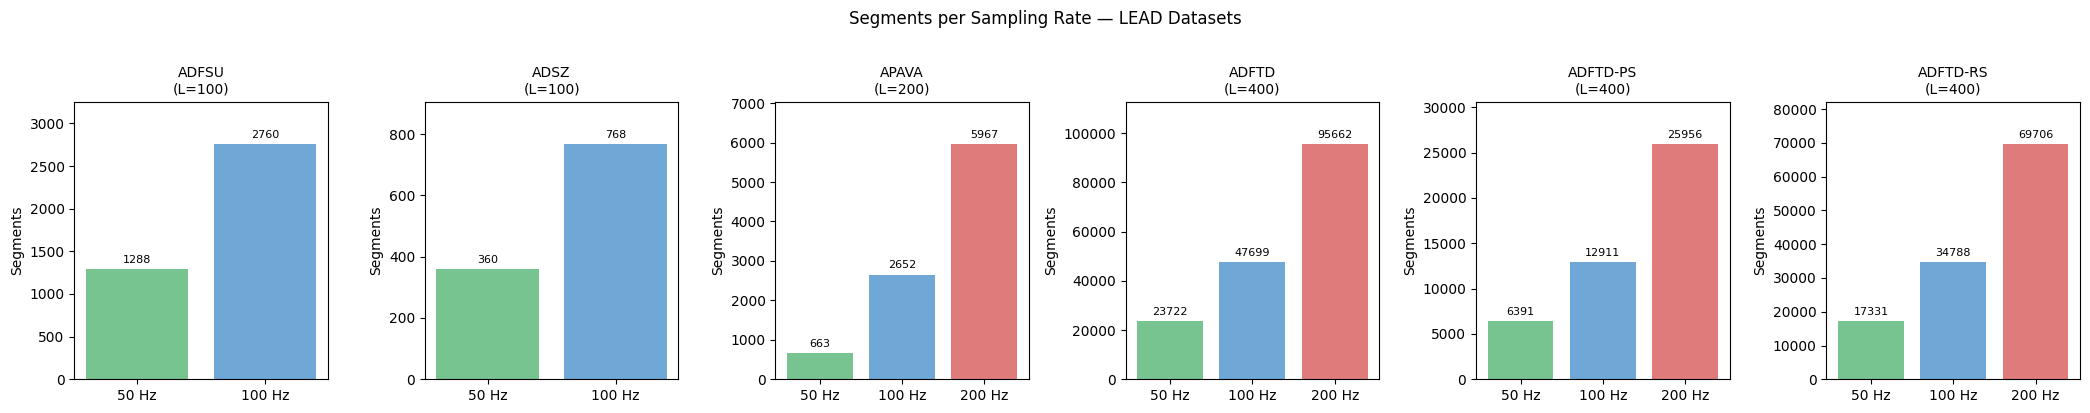

In [3]:
# Sampling rate distribution per dataset
fig, axes = plt.subplots(1, len(splits), figsize=(3.5 * len(splits), 4), sharey=False)
if len(splits) == 1:
    axes = [axes]

sr_palette = {50: "#78C490", 100: "#6FA8D6", 200: "#E07B7B"}

for ax, s in zip(axes, splits):
    y = s["_y"]
    srs, counts = np.unique(y[:, 2], return_counts=True)
    bars = ax.bar([f"{int(sr)} Hz" for sr in srs], counts,
                  color=[sr_palette.get(int(sr), "#CCCCCC") for sr in srs])
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_title(f"{s['Dataset']}\n(L={s['Window (L)']})", fontsize=10)
    ax.set_ylabel("Segments")
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle("Segments per Sampling Rate — LEAD Datasets", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Class Distribution

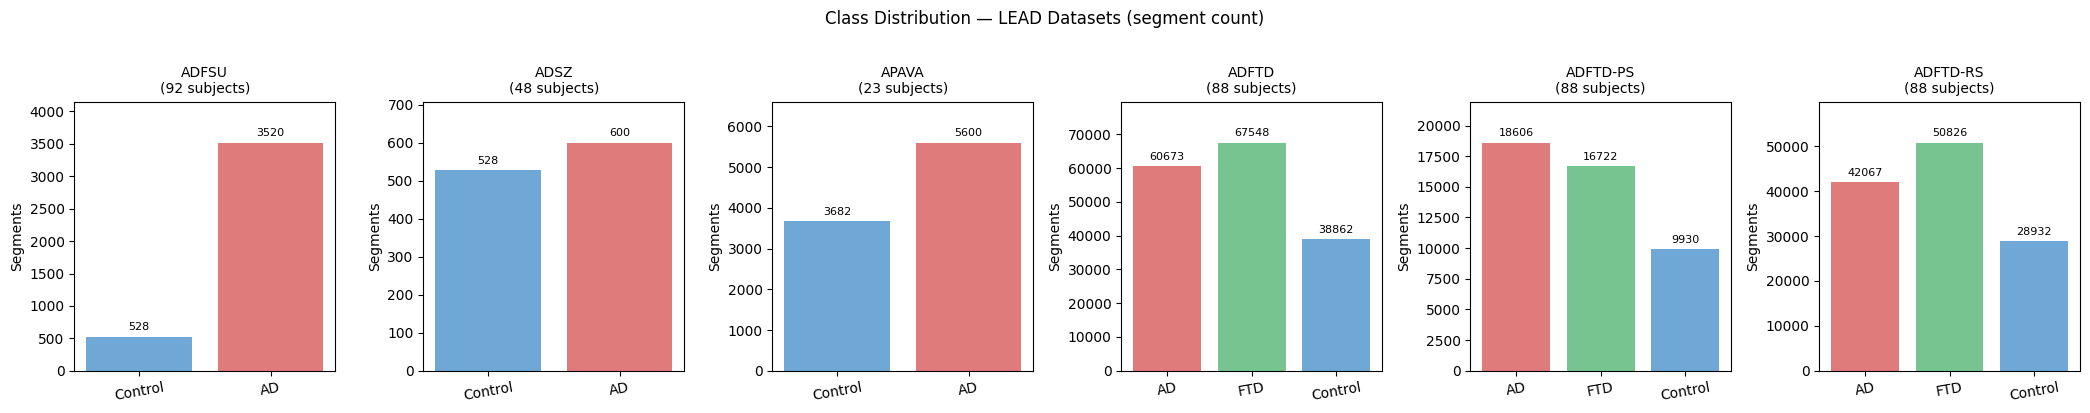

In [4]:
# For datasets with known class mappings
# Binary datasets (ADFSU, ADSZ, APAVA, BACA-RS): 0 = Control, 1 = AD
# 3-class datasets (ADFTD): 0 = AD, 1 = FTD, 2 = Control
label_maps = {
    2: {0: "Control", 1: "AD"},
    3: {0: "AD", 1: "FTD", 2: "Control"},
}
class_colors = {
    "Control": "#6FA8D6",
    "AD":      "#E07B7B",
    "FTD":     "#78C490",
}

fig, axes = plt.subplots(1, len(splits), figsize=(3.5 * len(splits), 4), sharey=False)
if len(splits) == 1:
    axes = [axes]

for ax, s in zip(axes, splits):
    lc = s["_label_counts"]
    lmap = label_maps.get(len(lc), {k: str(k) for k in lc})
    labels = [lmap[k] for k in sorted(lc)]
    counts = [lc[k] for k in sorted(lc)]
    colors = [class_colors.get(l, "#CCCCCC") for l in labels]
    bars = ax.bar(labels, counts, color=colors)
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_title(f"{s['Dataset']}\n({s['Subjects']} subjects)", fontsize=10)
    ax.set_ylabel("Segments")
    ax.set_ylim(0, max(counts) * 1.18)
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Class Distribution — LEAD Datasets (segment count)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Subject Counts per Dataset

In [5]:
# Segments per subject (load balancing)
for s in splits:
    y = s["_y"]
    lmap = label_maps.get(s["Classes"], {k: str(k) for k in s["_label_counts"]})
    print(f"\n{'─'*50}")
    print(f"Dataset: {s['Dataset']}  (L={s['Window (L)']}, C={s['Channels (C)']} channels)")
    print(f"  Total segments : {s['Segments (N)']:,}")
    print(f"  Total subjects : {s['Subjects']}")
    print(f"  Avg segs/subj  : {s['Segments (N)'] / s['Subjects']:.0f}")
    # per-class subject count
    for label_id in sorted(s["_label_counts"]):
        mask = y[:, 0] == label_id
        n_sub = len(np.unique(y[mask, 1]))
        n_seg = mask.sum()
        print(f"  [{lmap[label_id]}] {n_sub} subjects, {n_seg:,} segments, {n_seg/n_sub:.0f} segs/subj")


──────────────────────────────────────────────────
Dataset: ADFSU  (L=100, C=19 channels)
  Total segments : 4,048
  Total subjects : 92
  Avg segs/subj  : 44
  [Control] 12 subjects, 528 segments, 44 segs/subj
  [AD] 80 subjects, 3,520 segments, 44 segs/subj

──────────────────────────────────────────────────
Dataset: ADSZ  (L=100, C=19 channels)
  Total segments : 1,128
  Total subjects : 48
  Avg segs/subj  : 24
  [Control] 24 subjects, 528 segments, 22 segs/subj
  [AD] 24 subjects, 600 segments, 25 segs/subj

──────────────────────────────────────────────────
Dataset: APAVA  (L=200, C=16 channels)
  Total segments : 9,282
  Total subjects : 23
  Avg segs/subj  : 404
  [Control] 11 subjects, 3,682 segments, 335 segs/subj
  [AD] 12 subjects, 5,600 segments, 467 segs/subj

──────────────────────────────────────────────────
Dataset: ADFTD  (L=400, C=19 channels)
  Total segments : 167,083
  Total subjects : 88
  Avg segs/subj  : 1899
  [AD] 29 subjects, 60,673 segments, 2092 segs/subj

## 5. Signal Peek — One Segment per Class

In [6]:
# Pick a dataset to visualize — ADFTD-RS is richest (3-class)
viz_split = next(s for s in splits if s["Dataset"] == "ADFTD-RS")

N, T, C = viz_split["Segments (N)"], viz_split["Window (L)"], viz_split["Channels (C)"]
print(f"Loading X.dat for {viz_split['Dataset']}: {N:,} × {T} × {C}  (this may take a moment)")

X = np.memmap(os.path.join(viz_split["_path"], "X.dat"), dtype=np.float32, mode="r").reshape(N, T, C)
y = viz_split["_y"]
print("Done.")

Loading X.dat for ADFTD-RS: 121,825 × 400 × 19  (this may take a moment)
Done.


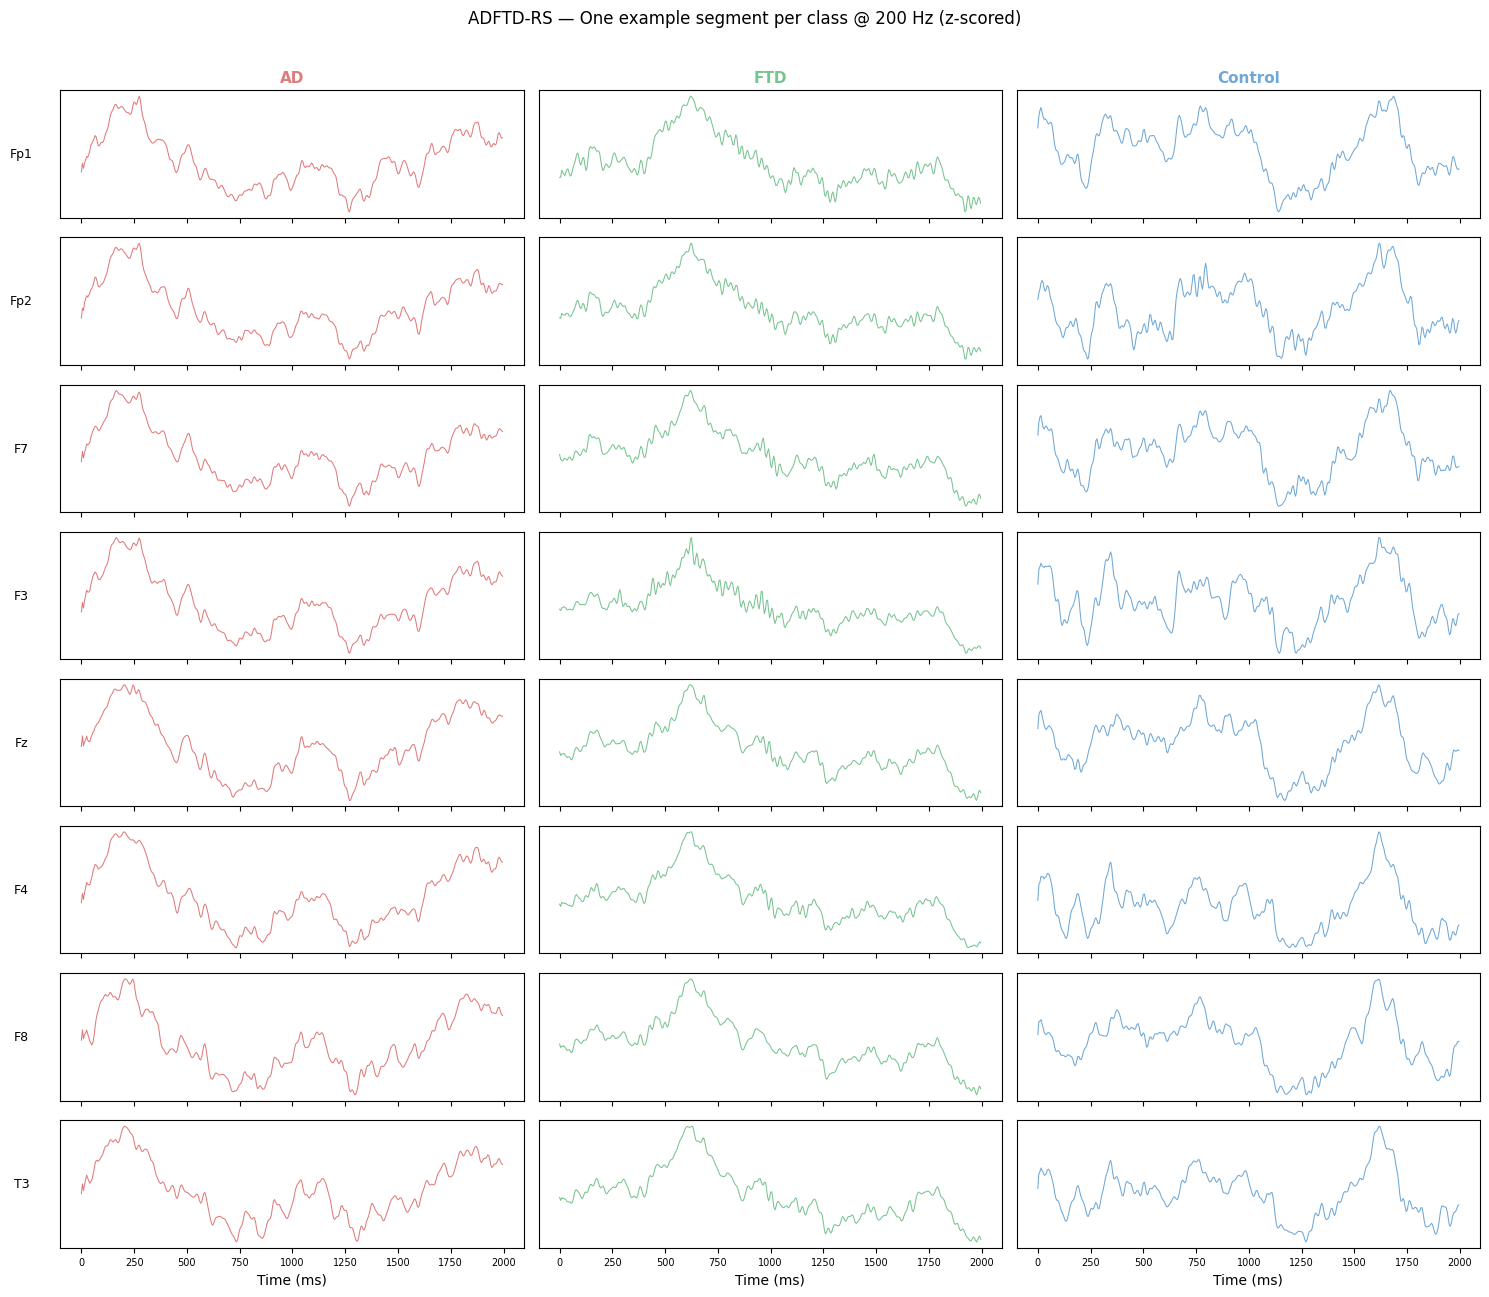

In [7]:
# Standard 19-channel 10-20 names (LEAD channel order from README)
CH_NAMES = ["Fp1","Fp2","F7","F3","Fz","F4","F8",
            "T3","C3","Cz","C4","T4",
            "T5","P3","Pz","P4","T6",
            "O1","O2"]

lmap = label_maps[3]  # ADFTD is 3-class
N_SHOW_CH = 8         # channels to plot

# Use a 200 Hz segment so time axis is clean
mask_200 = y[:, 2] == 200.0
y_200 = y[mask_200]
idx_200 = np.where(mask_200)[0]

unique_labels = sorted(np.unique(y_200[:, 0]).astype(int).tolist())
time_ms = np.arange(T) / 200 * 1000  # ms at 200 Hz

fig, axes = plt.subplots(N_SHOW_CH, len(unique_labels),
                          figsize=(5 * len(unique_labels), 1.6 * N_SHOW_CH),
                          sharex=True)

palette = {0: "#E07B7B", 1: "#78C490", 2: "#6FA8D6"}

for col, label in enumerate(unique_labels):
    # pick first segment with this label at 200 Hz
    local_idx = np.where(y_200[:, 0] == label)[0][0]
    global_idx = idx_200[local_idx]
    segment = X[global_idx]  # (T, C)
    
    # z-score normalize per channel (as LEAD does at load time)
    mu = segment.mean(axis=0, keepdims=True)
    sd = segment.std(axis=0, keepdims=True) + 1e-8
    segment_z = (segment - mu) / sd

    for row in range(N_SHOW_CH):
        ax = axes[row, col]
        ax.plot(time_ms, segment_z[:, row], linewidth=0.75, color=palette[label])
        if col == 0:
            ch = CH_NAMES[row] if row < len(CH_NAMES) else f"CH{row}"
            ax.set_ylabel(ch, fontsize=9, rotation=0, labelpad=28, va="center")
        if row == 0:
            ax.set_title(lmap[label], fontsize=11, fontweight="bold", color=palette[label])
        if row == N_SHOW_CH - 1:
            ax.set_xlabel("Time (ms)")
        ax.tick_params(labelsize=7)
        ax.set_yticks([])

plt.suptitle(f"ADFTD-RS — One example segment per class @ 200 Hz (z-scored)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Signal Statistics per Class

In [8]:
# Raw amplitude stats (before z-score) for a sample of segments
SAMPLE = 500  # segments per class

print(f"Raw amplitude statistics (sample of {SAMPLE} segments per class, ADFTD-RS)\n")
rows = []
for label in unique_labels:
    idxs = np.where(y[:, 0] == label)[0]
    chosen = np.random.default_rng(42).choice(idxs, size=min(SAMPLE, len(idxs)), replace=False)
    segs = X[chosen]  # (SAMPLE, T, C)
    rows.append({
        "Class": lmap[label],
        "Mean (µV)": f"{segs.mean():.4f}",
        "Std (µV)": f"{segs.std():.4f}",
        "Min (µV)": f"{segs.min():.4f}",
        "Max (µV)": f"{segs.max():.4f}",
        "P5 (µV)": f"{np.percentile(segs, 5):.4f}",
        "P95 (µV)": f"{np.percentile(segs, 95):.4f}",
    })

print(pd.DataFrame(rows).to_string(index=False))

Raw amplitude statistics (sample of 500 segments per class, ADFTD-RS)

  Class Mean (µV) Std (µV) Min (µV) Max (µV) P5 (µV) P95 (µV)
     AD   -0.0000   0.0000  -0.0006   0.0005 -0.0001   0.0001
    FTD    0.0000   0.0000  -0.0004   0.0007 -0.0001   0.0001
Control    0.0000   0.0000  -0.0004   0.0004 -0.0001   0.0001


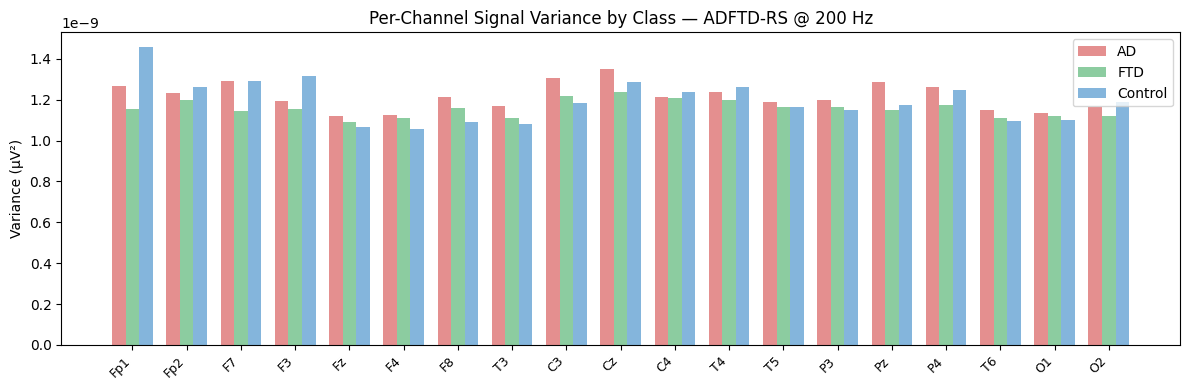

In [9]:
# Per-channel mean power (variance) by class — ADFTD-RS @ 200 Hz sample
fig, ax = plt.subplots(figsize=(12, 4))

ch_indices = np.arange(C)
width = 0.25

for i, label in enumerate(unique_labels):
    idxs = np.where((y[:, 0] == label) & (y[:, 2] == 200.0))[0]
    chosen = np.random.default_rng(42).choice(idxs, size=min(300, len(idxs)), replace=False)
    segs = X[chosen]  # (n, T, C)
    channel_var = segs.var(axis=(0, 1))  # variance per channel
    ax.bar(ch_indices + i * width, channel_var, width, label=lmap[label], color=palette[label], alpha=0.85)

ax.set_xticks(ch_indices + width)
ax.set_xticklabels(CH_NAMES[:C], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Variance (µV²)")
ax.set_title("Per-Channel Signal Variance by Class — ADFTD-RS @ 200 Hz")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Dataset | Task | Window | Channels | Subjects | Segments | Sampling Rates |
|---------|------|--------|----------|----------|----------|-----------------|
| ADFSU   | AD vs Control (binary) | L100 | 19 | 92 | 4,048 | 50, 100 Hz |
| ADSZ    | AD vs Control (binary) | L100 | 19 | 48 | 1,128 | 50, 100 Hz |
| APAVA   | AD vs Control (binary) | L200 | 16 | 23 | 9,282 | 50, 100, 200 Hz |
| ADFTD-RS | AD / FTD / Control (3-class, resting) | L400 | 19 | 88 | 121,825 | 50, 100, 200 Hz |
| ADFTD-PS | AD / FTD / Control (3-class, passive) | L400 | 19 | 88 | 45,258 | 50, 100, 200 Hz |
| ADFTD   | AD / FTD / Control (3-class, combined) | L400 | 19 | 88 | 167,083 | 50, 100, 200 Hz |

**y.dat columns:** `[label, subject_id, sampling_rate]` — dtype float32, shape `[N, 3]`  
**X.dat shape:** `[N, T, C]` — dtype float32, z-score normalized per channel at load time